<a href="https://colab.research.google.com/github/dgaddes/uHTS_Analysis/blob/main/uHTS_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
"""
Ordinal logistic regression on CDS expression bins — reproduced from the
CDS Bin Enrichment Pipeline (Step 5/6), using the PRECOMPUTED features already
present in sequencefeaturesbybin.xlsx instead of recomputing tAI/ramp/stalls.

Outcome : ordinal bin membership (Low=1, Medium=2, High=3)
Model   : proportional-odds (ordered logit) via statsmodels OrderedModel
Method  : standardized predictors; coefficient = change in log-odds of being
          in a HIGHER bin per +1 SD of the predictor.

Feature views available in the xlsx (used here):
  Codon usage / adaptation : avg_CAI, min_CAI, site1..4_CAI, site1_TI_2
  mRNA structure (folding) : dG_cds_only, dG_cds_16_55
  Composition / length     : total_length, GC proxy via AA counts
  Fragment identity        : avg_identity, min/max_identity, avg_comp_sim,
                             n_unique_frags, max_frag_repeat, has_repeat
"""

import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')

import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
from statsmodels.miscmodels.ordinal_model import OrderedModel

!pip install ViennaRNA scikit-learn biopython openpyxl --quiet

from collections import Counter, defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score
from Bio.Data import CodonTable
from Bio import pairwise2
import warnings
warnings.filterwarnings('ignore')

XLSX_PATH = '/content/sequence-features-by-bin.xlsx'
BIN_COL   = 'bin'
BIN_RANK  = {'Low': 1, 'Medium': 2, 'High': 3}

# ──────────────────────────────────────────────────────────────────────────────
# 1. Load + assign ordinal outcome
# ──────────────────────────────────────────────────────────────────────────────
df = pd.read_excel(XLSX_PATH, sheet_name='Sheet1')
df['bin_rank'] = df[BIN_COL].map(BIN_RANK)
df = df.dropna(subset=['bin_rank'])
df['bin_rank'] = df['bin_rank'].astype(int)

print(f"Loaded {len(df):,} sequences")
print("Bin distribution:", df[BIN_COL].value_counts().reindex(['Low','Medium','High']).to_dict())

# Derive a couple of composition features the pipeline used (GC proxy, AA total)
AA_COUNT_COLS = [c for c in df.columns if c.endswith('_count')]
df['aa_total'] = df[AA_COUNT_COLS].sum(axis=1)
# GC-rich residue fraction as a stand-in for GC content (no raw nt GC column needed,
# but cds is present so compute true GC directly):
def gc_frac(s):
    s = str(s).upper()
    return (s.count('G') + s.count('C')) / max(len(s), 1)
df['gc_content'] = df['cds'].map(gc_frac)

# ──────────────────────────────────────────────────────────────────────────────
# 2. Feature set — precomputed columns from the xlsx
# ──────────────────────────────────────────────────────────────────────────────
FEATURES = [
    'avg_CAI',         # codon adaptation (mean over sites)
    'min_CAI',         # worst-site codon adaptation
    'site1_TI_2',      # 5' translation-initiation proxy
    'dG_cds_only',     # CDS folding free energy (less negative = less structure)
    'dG_cds_16_55',    # initiation-region folding free energy
    'gc_content',      # GC fraction of the CDS
    'total_length',    # construct length
    'avg_identity',    # mean pairwise fragment identity
    'min_identity',    # most divergent fragment pair
    'avg_comp_sim',    # average compositional similarity of fragments
    'n_unique_frags',  # fragment diversity
    'max_frag_repeat', # largest repeated-fragment run
    'has_repeat',      # any repeated fragment (0/1)
]
FEATURES = [c for c in FEATURES if c in df.columns]

def run_ordinal(data, feature_cols, label):
    sub = data[feature_cols + ['bin_rank']].dropna()
    X = sub[feature_cols].astype(float)
    # standardize (z-score); drop zero-variance columns to keep the fit stable
    keep = [c for c in feature_cols if X[c].std() > 0]
    X = X[keep]
    X = (X - X.mean()) / X.std()
    y = sub['bin_rank'].astype(int)

    mod = OrderedModel(y, X, distr='logit')
    res = mod.fit(method='bfgs', disp=False, maxiter=200)

    k = len(keep)
    coef = pd.DataFrame({
        'feature': keep,
        'coef':    res.params[:k].values,
        'se':      res.bse[:k].values,
        'z':       res.tvalues[:k].values,
        'p_value': res.pvalues[:k].values,
        'OR':      np.exp(res.params[:k].values),
    }).sort_values('coef', key=lambda s: s.abs(), ascending=False)

    print("\n" + "="*78)
    print(f"ORDINAL LOGISTIC REGRESSION — {label}")
    print("="*78)
    print(f"  n = {len(sub):,} complete rows | {k} predictors")
    print(f"  McFadden pseudo-R^2 = {res.prsquared:.4f}")
    print(f"  Log-likelihood      = {res.llf:.1f}  (null {res.llnull:.1f})")
    print(f"  LLR p-value         = {res.llr_pvalue:.2e}")
    # threshold (cutpoint) params come after the betas
    print(f"  Cutpoints (latent)  : {np.round(res.params[k:].values, 3).tolist()}")
    print()
    hdr = f"  {'feature':16s} {'coef':>8s} {'se':>7s} {'z':>8s} {'p':>10s} {'OR/SD':>8s}"
    print(hdr); print("  " + "-"*len(hdr))
    for _, r in coef.iterrows():
        sig = '***' if r.p_value < 1e-3 else ('**' if r.p_value < 1e-2 else ('*' if r.p_value < 0.05 else ''))
        print(f"  {r.feature:16s} {r.coef:>8.3f} {r.se:>7.3f} {r.z:>8.2f} "
              f"{r.p_value:>10.2e} {r.OR:>8.3f} {sig}")
    return res, coef

res, coef_df = run_ordinal(df, FEATURES, "all precomputed xlsx features")

# ──────────────────────────────────────────────────────────────────────────────
# 3. Reduced model matching the original pipeline's feature spirit
#    (codon usage + structure only), for comparison
# ──────────────────────────────────────────────────────────────────────────────
CORE = [c for c in ['avg_CAI','min_CAI','site1_TI_2','dG_cds_only','dG_cds_16_55','gc_content']
        if c in df.columns]
res_core, coef_core = run_ordinal(df, CORE, "codon-usage + structure core")

# ──────────────────────────────────────────────────────────────────────────────
# 4. Interpretation helper
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*78)
print("READING THE COEFFICIENTS")
print("="*78)
print("  Positive coef  -> higher value pushes a sequence toward a HIGHER bin.")
print("  OR/SD          -> odds multiplier for moving up a bin per +1 SD.")
print("  Note: dG is negative (more negative = MORE structure); a positive coef")
print("        on dG means LESS structure (higher dG) associates with higher bins.")

# Save outputs
coef_df.to_csv('/content/ordinal_coefficients_full.csv', index=False)
coef_core.to_csv('/content/ordinal_coefficients_core.csv', index=False)
print("\nSaved: ordinal_coefficients_full.csv, ordinal_coefficients_core.csv")

Loaded 13,963 sequences
Bin distribution: {'Low': 2543, 'Medium': 5301, 'High': 6119}

ORDINAL LOGISTIC REGRESSION — all precomputed xlsx features
  n = 13,963 complete rows | 13 predictors
  McFadden pseudo-R^2 = 0.0415
  Log-likelihood      = -13910.9  (null -14513.2)
  LLR p-value         = 1.65e-249
  Cutpoints (latent)  : [-1.602, 0.627]

  feature              coef      se        z          p    OR/SD
  ----------------------------------------------------------------
  dG_cds_only        -0.306   0.022   -13.78   3.17e-43    0.736 ***
  dG_cds_16_55       -0.267   0.018   -14.81   1.22e-49    0.765 ***
  avg_CAI             0.186   0.024     7.82   5.19e-15    1.205 ***
  avg_comp_sim        0.125   0.028     4.54   5.68e-06    1.133 ***
  has_repeat         -0.120   0.100    -1.20   2.31e-01    0.887 
  site1_TI_2          0.099   0.019     5.13   2.84e-07    1.104 ***
  avg_identity        0.089   0.037     2.40   1.63e-02    1.093 *
  gc_content          0.085   0.018     4.81

Saved bin_violins.png


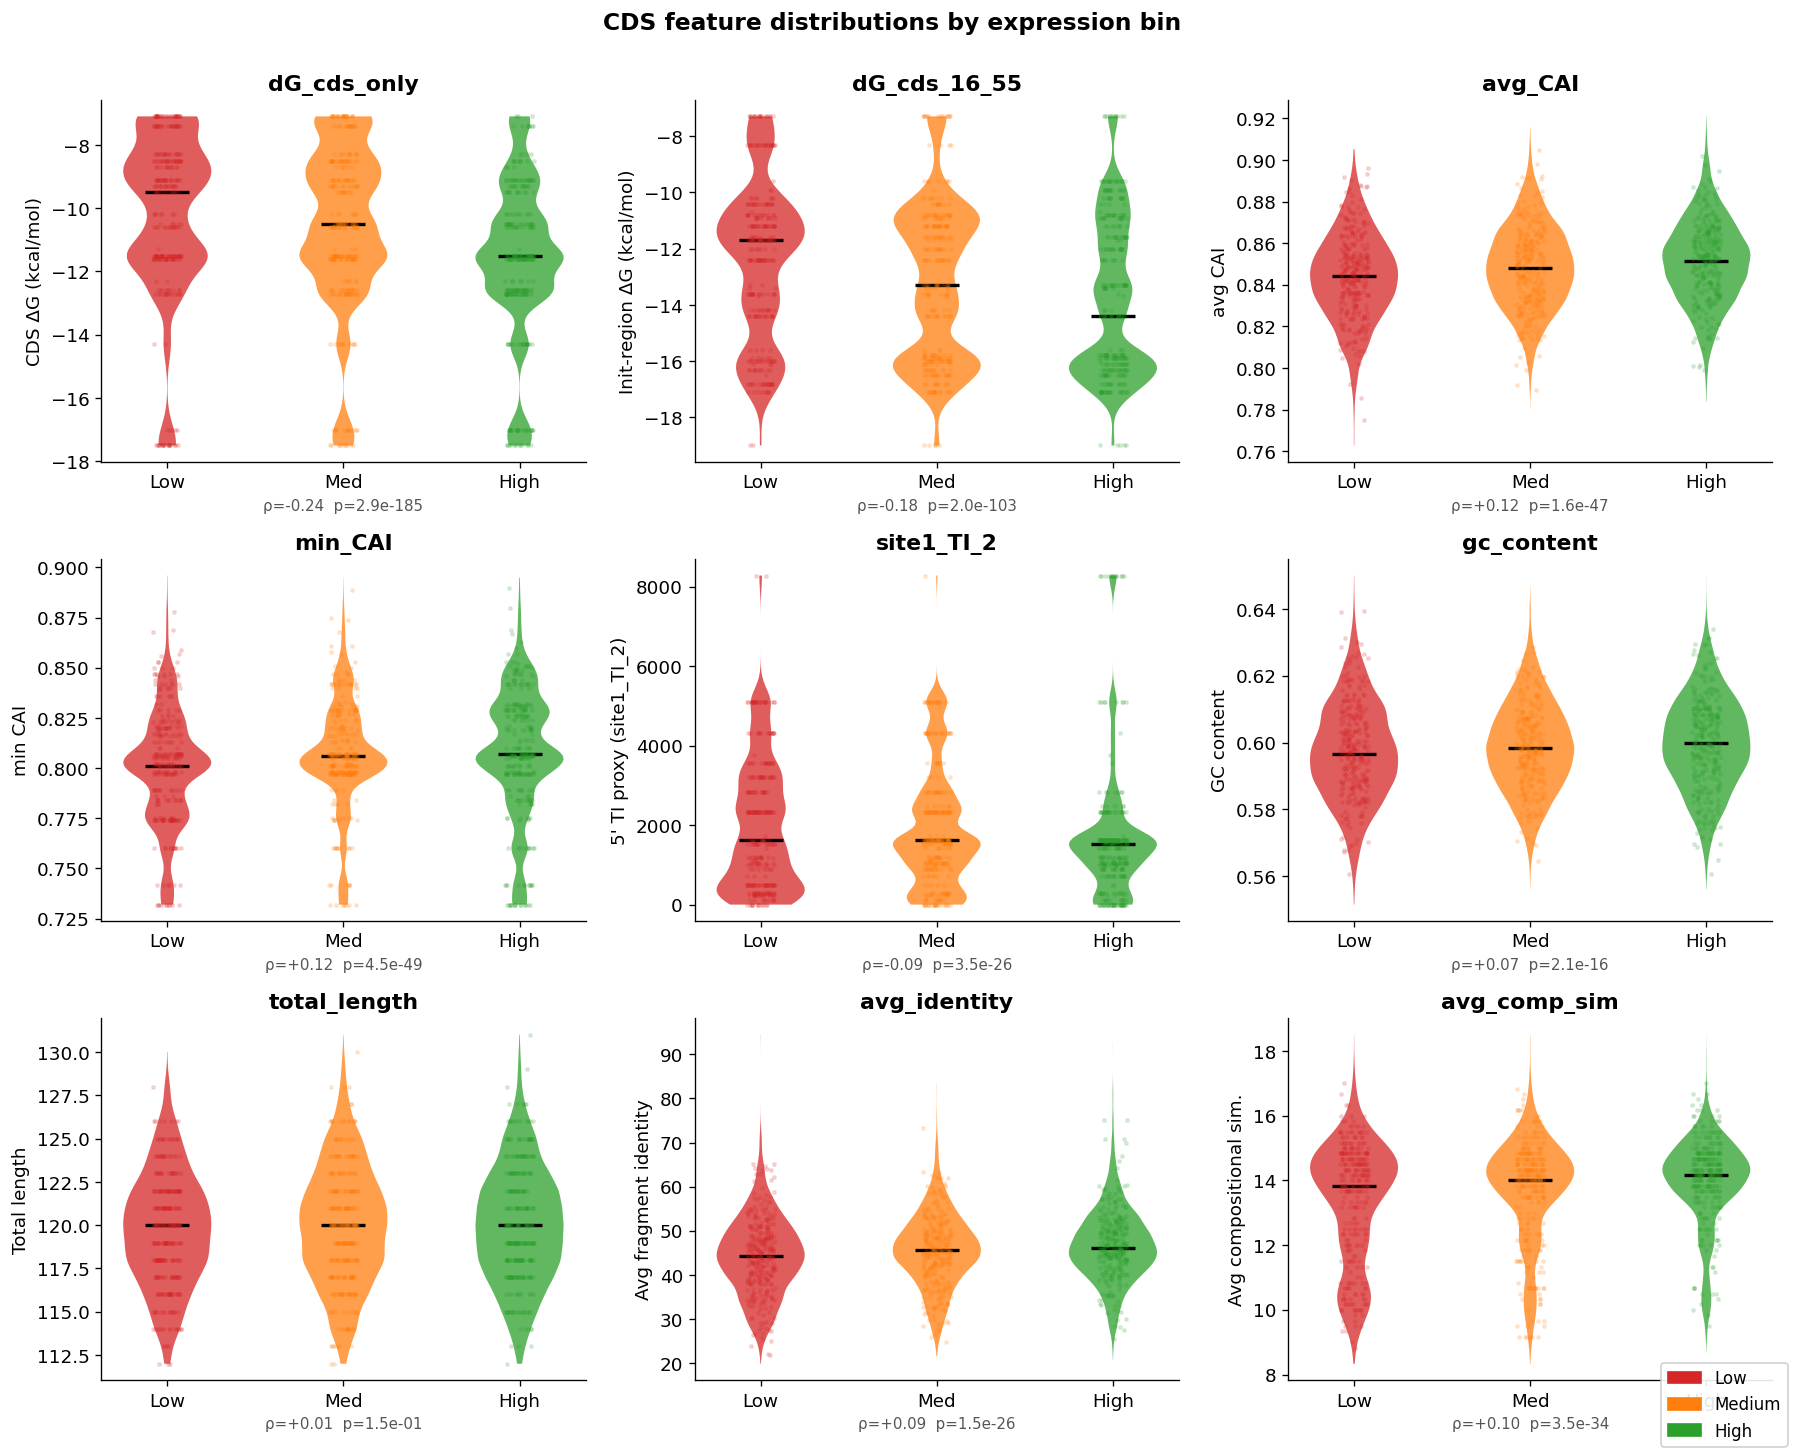

In [ ]:
"""
Violin plots of CDS features split by expression bin (Low / Medium / High),
reading directly from sequencefeaturesbybin.xlsx.

Mirrors the pipeline's fig_bin_violins style: one panel per feature, colored by
bin, with jittered points, median lines, and Spearman rho vs bin_rank annotated.
"""

BIN_RANK  = {'Low': 1, 'Medium': 2, 'High': 3}

BIN_ORDER  = ['Low', 'Medium', 'High']
BIN_COLORS = {'Low': '#d62728', 'Medium': '#ff7f0e', 'High': '#2ca02c'}

# Features to plot (these are the significant ordinal predictors + a couple more)
FEATURES = [
    'dG_cds_only', 'dG_cds_16_55', 'avg_CAI', 'min_CAI',
    'site1_TI_2', 'gc_content', 'total_length', 'avg_identity',
    'avg_comp_sim',
]
LABELS = {
    'dG_cds_only':  "CDS ΔG (kcal/mol)",
    'dG_cds_16_55': "Init-region ΔG (kcal/mol)",
    'avg_CAI':      'avg CAI',
    'min_CAI':      'min CAI',
    'site1_TI_2':   "5' TI proxy (site1_TI_2)",
    'gc_content':   'GC content',
    'total_length': 'Total length',
    'avg_identity': 'Avg fragment identity',
    'avg_comp_sim': 'Avg compositional sim.',
}

# ── Load + derive the two computed columns the xlsx doesn't store directly ─────
df = pd.read_excel(XLSX_PATH, sheet_name='Sheet1')
df['bin_rank'] = df['bin'].map(BIN_RANK)
df = df.dropna(subset=['bin_rank'])
df['gc_content'] = df['cds'].map(
    lambda s: (str(s).upper().count('G') + str(s).upper().count('C')) / max(len(str(s)), 1))

FEATURES = [c for c in FEATURES if c in df.columns]

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11,
                     'figure.dpi': 120})

ncols = 3
nrows = (len(FEATURES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()
rng = np.random.default_rng(42)

for ax, col in zip(axes, FEATURES):
    data_by_bin = [df.loc[df['bin'] == b, col].dropna().values for b in BIN_ORDER]

    parts = ax.violinplot(data_by_bin, positions=range(3),
                          showmedians=True, showextrema=False)
    for pc, b in zip(parts['bodies'], BIN_ORDER):
        pc.set_facecolor(BIN_COLORS[b]); pc.set_alpha(0.75)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

    # jittered points (cap 300/bin for clarity)
    for x_pos, b in enumerate(BIN_ORDER):
        vals = df.loc[df['bin'] == b, col].dropna()
        if len(vals) > 300:
            vals = vals.sample(300, random_state=42)
        jit = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(x_pos + jit, vals, color=BIN_COLORS[b], alpha=0.15, s=4, zorder=2)

    ax.set_xticks(range(3)); ax.set_xticklabels(['Low', 'Med', 'High'])
    ax.set_ylabel(LABELS.get(col, col))
    ax.set_title(col, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

    valid = df[col].notna()
    r, p = spearmanr(df.loc[valid, col], df.loc[valid, 'bin_rank'])
    ax.set_xlabel(f'ρ={r:+.2f}  p={p:.1e}', fontsize=9, color='#555555')

for ax in axes[len(FEATURES):]:
    ax.set_visible(False)

patches = [mpatches.Patch(color=BIN_COLORS[b], label=b) for b in BIN_ORDER]
fig.legend(handles=patches, loc='lower right', fontsize=10, framealpha=0.9)
fig.suptitle('CDS feature distributions by expression bin',
             fontsize=14, fontweight='bold', y=1.0)
fig.tight_layout()

fig.savefig('/content/bin_violins.png', dpi=150, bbox_inches='tight')
print('Saved bin_violins.png')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Feature Comparison Harness — per-fold CV metrics with mean ± SD (error bars)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Same as the original harness, but instead of pooling held-out predictions into
# ONE accuracy, it scores EACH of the 5 folds separately and reports:
#
#   • mean accuracy ± SD across folds            (the requested error bars)
#   • mean per-bin recall ± SD across folds
#   • mean confusion matrix (averaged over folds) + summed confusion matrix
#   • per-fold accuracy/recall arrays kept for plotting
#
# The FOLDS are identical to the original (same folds_idx, same CV_SEED), so the
# pooled "each sequence predicted once" predictions are still produced and used
# for the overlap / complementarity analysis and the misclassified table. The
# only change is that we ALSO record, for every fold, the metrics computed on
# that fold's held-out slice — which is what lets us put error bars on the means.
#
# Compares (RF + KNN):
#   From v9 (read from xlsx):
#     Fragment identity, AA identity, Codon identity, CAI, mRNA dG,
#     CAI + mRNA dG, All computed
#   From structure cache:
#     Windowed dG (sliding)
#   E. coli features (recomputed here):
#     Codon-pair bias, 5' ramp, UTR+CDS init fold, mRNA stability, Stall sites
#
# SAVES (reloadable):
#   feature_comparison_cv.pkl              — everything in one dict (pickle)
#   feature_comparison_preds.npz           — pooled prediction matrix + y + df_index
#   feature_comparison_cv_summary.csv      — per feature×clf: mean/SD acc + per-bin recall
#   feature_comparison_perfold.csv         — long table: feature, clf, fold, acc, recalls
#   feature_comparison_misclassified.csv   — long table: feature, clf, excel_row, true, pred
#   feature_comparison_overlap.csv         — pairwise overlap matrix (pooled, RF)
#
# REQUIRES (you have these): msa_cache.npz, mrna_struct_cache.npz, the xlsx.
# ═══════════════════════════════════════════════════════════════════════════════

try:
    import RNA
    HAVE_RNA = True
except Exception:
    HAVE_RNA = False
    print("*** ViennaRNA not importable — init-fold/stability dG will be 0 ***")

# ── Config ────────────────────────────────────────────────────────────────────
BIN_NAMES = ['low', 'medium', 'high']
NUM_BINS  = 3
CACHE_DIR = '.'
OUT_DIR   = '.'
BIN_COL, SEQ_COL = 'bin', 'cds'
N_FOLDS, CV_SEED, KNN_K = 5, 42, 15
CDS_FRAME_OFFSET = 2
BIN_LABEL_MAP = {'low': 0, 'medium': 1, 'high': 2}

PROMOTER_UTR = ("AATCATAAAAAATTTATTTGCTTTGTGAGCGGATAACAATTATAATAGATTCAATTGTGAGC"
                "GGATAACAATTTCACACAGTCTAGAAGTAATTTTGTGGCACTTTAAGAAGGAGATATA")
UTR_TAIL = PROMOTER_UTR[-25:]
RAMP_CODONS, INIT_CDS_NT = 15, 45

STANDARD_CODONS = [
    'TTT','TTC','TTA','TTG','CTT','CTC','CTA','CTG','ATT','ATC','ATA','ATG',
    'GTT','GTC','GTA','GTG','TCT','TCC','TCA','TCG','CCT','CCC','CCA','CCG',
    'ACT','ACC','ACA','ACG','GCT','GCC','GCA','GCG','TAT','TAC','TAA','TAG',
    'CAT','CAC','CAA','CAG','AAT','AAC','AAA','AAG','GAT','GAC','GAA','GAG',
    'TGT','TGC','TGA','TGG','CGT','CGC','CGA','CGG','AGT','AGC','AGA','AGG',
    'GGT','GGC','GGA','GGG',
]
_table = CodonTable.standard_dna_table


# ══════════════════════════════════════════════════════════════════════════════
# 1. MASTER ALIGNMENT — codon cache df_index is the canonical row order
# ══════════════════════════════════════════════════════════════════════════════
msa = np.load(os.path.join(CACHE_DIR, 'msa_cache.npz'), allow_pickle=True)
X_codon_msa = msa['X_codon'].astype(np.float32)   # codon IDs at aligned positions
y           = msa['y'].astype(np.int32)
DF_INDEX    = msa['df_index']                      # → Excel row for each sample
N = len(y)
print(f"Master order from msa_cache: N={N}, codon {X_codon_msa.shape}")
print(f"bins: {np.bincount(y).tolist()}")

DF = pd.read_excel(XLSX_PATH)

# Recover the codon/dna sequence per master row (for E. coli features) in
# df_index order so everything is row-aligned.
def cds_of(idx):
    dna = str(DF.loc[idx, SEQ_COL]).upper().replace('U','T').strip()[CDS_FRAME_OFFSET:]
    codons = [dna[j:j+3] for j in range(0, len(dna)-2, 3) if len(dna[j:j+3]) == 3]
    return codons, dna
CODONS = [None]*N; DNA = [None]*N
for i, idx in enumerate(DF_INDEX):
    CODONS[i], DNA[i] = cds_of(idx)


# ══════════════════════════════════════════════════════════════════════════════
# 2. v9 FEATURE SETS (read straight from xlsx, in master order)
# ══════════════════════════════════════════════════════════════════════════════
def cols(*names):
    present = [c for c in names if c in DF.columns]
    return DF.loc[DF_INDEX, present].to_numpy(dtype=np.float32) if present \
           else np.zeros((N, 1), np.float32)

CAI_COLS = ['site1_CAI','site2_CAI','site3_CAI','site4_CAI','avg_CAI','min_CAI']
DG_COLS  = ['dG_cds_only','dG_cds_16_55']
FRAGID   = ['frag1_id','frag2_id','frag3_id','frag4_id','avg_identity','max_identity',
            'min_identity','identity_1-2','identity_1-3','identity_1-4',
            'identity_2-3','identity_2-4','identity_3-4']
AACOUNT  = [c for c in DF.columns if c.endswith('_count')]
NUMERIC  = [c for c in DF.select_dtypes(include=[np.number]).columns if c != BIN_COL]

FEATURES = {}
FEATURES['Fragment identity'] = cols(*FRAGID)
FEATURES['AA identity']       = cols(*AACOUNT)
FEATURES['Codon identity']    = X_codon_msa
FEATURES['CAI']               = cols(*CAI_COLS)
FEATURES['mRNA dG (scalar)']  = cols(*DG_COLS)
FEATURES['CAI + mRNA dG']     = np.hstack([cols(*CAI_COLS), cols(*DG_COLS)])
FEATURES['All computed']      = DF.loc[DF_INDEX, NUMERIC].to_numpy(np.float32)


# ══════════════════════════════════════════════════════════════════════════════
# 3. WINDOWED dG (from structure cache) — align to master via the length filter
# ══════════════════════════════════════════════════════════════════════════════
st_path = os.path.join(CACHE_DIR, 'mrna_struct_cache.npz')
if os.path.exists(st_path):
    st = np.load(st_path)
    F_win_raw = st['F_win']                      # (N_struct, 30)
    struct_rows = [idx for idx, r in DF.iterrows()
                   if len(str(r[SEQ_COL]).upper().replace('U','T').strip()[CDS_FRAME_OFFSET:]) >= 45]
    if len(struct_rows) != len(F_win_raw):
        print(f"  WARN: struct cache rows {len(F_win_raw)} != filter rows {len(struct_rows)}; "
              "windowed dG may be misaligned. Rebuild cache if so.")
    struct_pos = {idx: k for k, idx in enumerate(struct_rows)}
    F_win = np.zeros((N, F_win_raw.shape[1]), np.float32)
    for i, idx in enumerate(DF_INDEX):
        if idx in struct_pos:
            F_win[i] = F_win_raw[struct_pos[idx]]
    FEATURES['Windowed dG (slide)'] = F_win
    print(f"  Windowed dG aligned into master order: {F_win.shape}")
else:
    print("  mrna_struct_cache.npz not found — skipping Windowed dG.")


# ══════════════════════════════════════════════════════════════════════════════
# 4. E. coli FEATURES (recompute in master order)
# ══════════════════════════════════════════════════════════════════════════════
def codons_to_aa(cs):
    return [_table.forward_table[c] if c in _table.forward_table
            else ('*' if c in _table.stop_codons else 'X') for c in cs]

# optimality from High-bin codon usage (this system)
fam = defaultdict(Counter)
for i in range(N):
    if y[i] == 2:
        for c in CODONS[i]:
            aa = _table.forward_table.get(c, '*' if c in _table.stop_codons else 'X')
            fam[aa][c] += 1
OPT = {}
for aa, cnt in fam.items():
    mx = max(cnt.values())
    for c, v in cnt.items(): OPT[c] = v/mx
for c in STANDARD_CODONS: OPT.setdefault(c, 0.05)
RARE = {c: 1.0 - OPT.get(c, 0.5) for c in STANDARD_CODONS}

# codon-pair bias table
cod_count, pair_count, aa_count, aapair = Counter(), Counter(), Counter(), Counter()
for i in range(N):
    cs = CODONS[i]; aas = codons_to_aa(cs)
    for c in cs: cod_count[c] += 1
    for a in aas: aa_count[a] += 1
    for k in range(len(cs)-1):
        pair_count[(cs[k], cs[k+1])] += 1
        aapair[(aas[k], aas[k+1])] += 1
CPS = {}
for (c1, c2), obs in pair_count.items():
    a1 = _table.forward_table.get(c1, 'X'); a2 = _table.forward_table.get(c2, 'X')
    exp = (cod_count[c1]*cod_count[c2]/(aa_count.get(a1,1)*aa_count.get(a2,1) or 1)
           * aapair.get((a1,a2), 1))
    if exp > 0 and obs > 0: CPS[(c1,c2)] = np.log(obs/exp)

def fold_dg(s):
    if not HAVE_RNA or len(s) < 10: return 0.0
    try: _, m = RNA.fold(s); return float(m)
    except Exception: return 0.0

def f_cpb(cs):
    v = [CPS.get((cs[k], cs[k+1]), 0.0) for k in range(len(cs)-1)]
    return [float(np.mean(v)), float(np.min(v)), float(np.sum(np.array(v) < -1))] if v else [0.,0.,0.]
def f_ramp(cs):
    w = [OPT.get(c,0.5) for c in cs[:RAMP_CODONS]]
    rest = [OPT.get(c,0.5) for c in cs[RAMP_CODONS:]] or [np.mean(w) if w else 0.5]
    return [float(np.mean(w)), float(np.min(w)), float(np.mean(w)/(np.mean(rest)+1e-6))]
def f_init(dna):
    early = dna[:INIT_CDS_NT]
    a = fold_dg(UTR_TAIL+early); b = fold_dg(PROMOTER_UTR+early); co = fold_dg(early)
    return [a, b, co, a-co]
def f_stab(dna):
    five = dna[:50]
    gc = (dna.count('G')+dna.count('C'))/max(len(dna),1)
    gc5 = (five.count('G')+five.count('C'))/max(len(five),1)
    au5 = (five.count('A')+five.count('T'))/max(len(five),1)
    return [gc, gc5, au5, fold_dg(five)]
def f_stall(cs):
    rare = [RARE.get(c,0.5) for c in cs]
    run = best = 0
    for r in rare:
        run = run+1 if r > 0.7 else 0; best = max(best, run)
    dna = ''.join(cs)
    sd = dna.count('AGGAGG')+dna.count('AAGGAG')+dna.count('GGAGG')
    return [best, sum(r>0.7 for r in rare), sd]

if HAVE_RNA:
    print("Computing E. coli features (folding, several minutes)...")
import time; t0 = time.time()
Fcpb, Framp, Finit, Fstab, Fstall = [], [], [], [], []
for i in range(N):
    if i % 1000 == 0 and i > 0 and HAVE_RNA:
        print(f"  {i}/{N} (~{(N-i)/(i/(time.time()-t0))/60:.1f} min left)", end='\r')
    Fcpb.append(f_cpb(CODONS[i])); Framp.append(f_ramp(CODONS[i]))
    Finit.append(f_init(DNA[i]));  Fstab.append(f_stab(DNA[i]))
    Fstall.append(f_stall(CODONS[i]))
if HAVE_RNA: print(f"\n  done in {(time.time()-t0)/60:.1f} min.")

FEATURES['Codon-pair bias']   = np.array(Fcpb, np.float32)
FEATURES['5prime ramp']       = np.array(Framp, np.float32)
FEATURES['UTR+CDS init fold']  = np.array(Finit, np.float32)
FEATURES['mRNA stability']    = np.array(Fstab, np.float32)
FEATURES['Stall sites']       = np.array(Fstall, np.float32)

print("\nFeature sets to evaluate:")
for k, v in FEATURES.items():
    print(f"  {k:20s}: {v.shape}")


# ══════════════════════════════════════════════════════════════════════════════
# 5. 5-FOLD CV — PER-FOLD metrics (for error bars) + pooled predictions
# ══════════════════════════════════════════════════════════════════════════════
# IDENTICAL folds to the original harness.
def folds_idx(y, n, seed):
    rng = np.random.default_rng(seed); per = {}
    for c in np.unique(y):
        idx = rng.permutation(np.where(y == c)[0]); per[c] = np.array_split(idx, n)
    return [np.sort(np.concatenate([per[c][f] for c in per])) for f in range(n)]
FOLDS = folds_idx(y, N_FOLDS, CV_SEED)

def make_clf(kind):
    if kind == 'RF':
        return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                      random_state=CV_SEED, n_jobs=-1)
    return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=KNN_K))

def cv_evaluate(F, kind):
    """Train per fold; return (pooled_pred, per_fold_metrics, per_fold_confmats).

    pooled_pred[i]      : held-out prediction for sequence i (each seq once)
    per_fold_metrics    : dict of length-N_FOLDS lists:
                          acc, low_recall, med_recall, high_recall
    per_fold_confmats   : list of (3x3) confusion matrices, one per fold
    """
    pooled = np.full(N, -1, np.int32)
    pf = {'acc': [], 'low_recall': [], 'med_recall': [], 'high_recall': []}
    cms = []
    for f in range(N_FOLDS):
        te = FOLDS[f]; tr = np.setdiff1d(np.arange(N), te)
        clf = make_clf(kind); clf.fit(F[tr], y[tr])
        pred_te = clf.predict(F[te])
        pooled[te] = pred_te
        y_te = y[te]
        # per-fold metrics on THIS fold's held-out slice
        pf['acc'].append(accuracy_score(y_te, pred_te))
        rec = recall_score(y_te, pred_te, labels=[0,1,2], average=None, zero_division=0)
        pf['low_recall'].append(rec[0]); pf['med_recall'].append(rec[1]); pf['high_recall'].append(rec[2])
        cms.append(confusion_matrix(y_te, pred_te, labels=[0,1,2]))
    return pooled, pf, cms

CLASSIFIERS = ['RF', 'KNN']
PREDS    = {}   # (feature, clf) -> pooled held-out predictions (for overlap/misclass)
PERFOLD  = {}   # (feature, clf) -> dict of per-fold metric lists
FOLDCMS  = {}   # (feature, clf) -> list of per-fold confusion matrices
print("\nRunning 5-fold CV (per-fold metrics for error bars)...")
for fname, F in FEATURES.items():
    for kind in CLASSIFIERS:
        pooled, pf, cms = cv_evaluate(F, kind)
        PREDS[(fname, kind)]   = pooled
        PERFOLD[(fname, kind)] = pf
        FOLDCMS[(fname, kind)] = cms
        print(f"  {fname:20s} {kind:4s}  acc={np.mean(pf['acc']):.1%} ± {np.std(pf['acc']):.1%}")


# ══════════════════════════════════════════════════════════════════════════════
# 6. SUMMARY — mean ± SD across folds (the error bars), plus per-fold long table
# ══════════════════════════════════════════════════════════════════════════════
def msd(v):
    v = np.asarray(v, float)
    return float(v.mean()), float(v.std())            # population SD (ddof=0)
def sem(v):
    v = np.asarray(v, float)
    return float(v.std(ddof=1) / np.sqrt(len(v)))     # standard error of the mean

summary_rows = []
perfold_rows = []
for (fname, kind), pf in PERFOLD.items():
    acc_m, acc_s   = msd(pf['acc'])
    low_m, low_s   = msd(pf['low_recall'])
    med_m, med_s   = msd(pf['med_recall'])
    high_m, high_s = msd(pf['high_recall'])
    summary_rows.append({
        'feature': fname, 'classifier': kind,
        'accuracy_mean': acc_m, 'accuracy_sd': acc_s, 'accuracy_sem': sem(pf['acc']),
        'low_recall_mean': low_m, 'low_recall_sd': low_s,
        'med_recall_mean': med_m, 'med_recall_sd': med_s,
        'high_recall_mean': high_m, 'high_recall_sd': high_s,
        'n_folds': N_FOLDS,
    })
    for f in range(N_FOLDS):
        perfold_rows.append({
            'feature': fname, 'classifier': kind, 'fold': f,
            'accuracy': pf['acc'][f],
            'low_recall': pf['low_recall'][f],
            'med_recall': pf['med_recall'][f],
            'high_recall': pf['high_recall'][f],
        })

summary_df = pd.DataFrame(summary_rows).sort_values('accuracy_mean', ascending=False)
perfold_df = pd.DataFrame(perfold_rows)

print("\n" + "="*86)
print("PER-FEATURE ACCURACY (mean ± SD over %d folds) + PER-BIN RECALL" % N_FOLDS)
print("="*86)
print(f"  {'Feature':20s} {'Clf':4s} {'Acc (mean±SD)':>16s} "
      f"{'LOW':>12s} {'Med':>12s} {'High':>12s}")
print("  " + "─"*82)
for _, r in summary_df.iterrows():
    print(f"  {r['feature']:20s} {r['classifier']:4s} "
          f"{r['accuracy_mean']*100:5.1f} ± {r['accuracy_sd']*100:3.1f}%   "
          f"{r['low_recall_mean']*100:4.1f}±{r['low_recall_sd']*100:3.1f} "
          f"{r['med_recall_mean']*100:4.1f}±{r['med_recall_sd']*100:3.1f} "
          f"{r['high_recall_mean']*100:4.1f}±{r['high_recall_sd']*100:3.1f}")


# ══════════════════════════════════════════════════════════════════════════════
# 7. CONFUSION MATRICES — mean (averaged over folds) and summed (== pooled)
# ══════════════════════════════════════════════════════════════════════════════
confmats_mean = {k: np.mean(np.stack(v), axis=0) for k, v in FOLDCMS.items()}
confmats_sum  = {k: np.sum(np.stack(v), axis=0).astype(int) for k, v in FOLDCMS.items()}

print("\nMean per-fold confusion matrices (rows=true low/med/high, cols=pred), RF:")
for (fname, kind), cm in confmats_mean.items():
    if kind == 'RF':
        print(f"\n  {fname} [{kind}]  (avg over {N_FOLDS} folds):")
        print(f"        {'low':>7s}{'med':>8s}{'high':>8s}")
        for b in range(NUM_BINS):
            print(f"  {BIN_NAMES[b]:5s} " + "".join(f"{cm[b,j]:>8.1f}" for j in range(NUM_BINS)))


# ══════════════════════════════════════════════════════════════════════════════
# 8. MISCLASSIFIED ROWS (from pooled predictions — each sequence once)
# ══════════════════════════════════════════════════════════════════════════════
misclassified = []
for (fname, kind), pred in PREDS.items():
    wrong = np.where(pred != y)[0]
    for i in wrong:
        misclassified.append({
            'feature': fname, 'classifier': kind,
            'excel_row': int(DF_INDEX[i]), 'master_pos': int(i),
            'true_bin': BIN_NAMES[y[i]], 'pred_bin': BIN_NAMES[pred[i]],
        })
misclass_df = pd.DataFrame(misclassified)


# ══════════════════════════════════════════════════════════════════════════════
# 9. OVERLAP ANALYSIS — which features agree / are complementary (pooled, RF)
# ══════════════════════════════════════════════════════════════════════════════
OVERLAP_CLF = 'RF'
names = list(FEATURES.keys())
correct = {n: (PREDS[(n, OVERLAP_CLF)] == y) for n in names}

def jaccard(a, b):
    u = (a | b).sum()
    return (a & b).sum()/u if u else float('nan')

overlap_rows = []
for i, a in enumerate(names):
    for b in names[i+1:]:
        pa, pb = PREDS[(a, OVERLAP_CLF)], PREDS[(b, OVERLAP_CLF)]
        ca, cb = correct[a], correct[b]
        overlap_rows.append({
            'feature_A': a, 'feature_B': b,
            'agree_pred': (pa == pb).mean(),
            'both_correct': (ca & cb).mean(),
            'A_only_right': (ca & ~cb).mean(),
            'B_only_right': (~ca & cb).mean(),
            'jaccard_correct': jaccard(ca, cb),
            'jaccard_wrong': jaccard(~ca, ~cb),
            'oracle_either': (ca | cb).mean(),
        })
overlap_df = pd.DataFrame(overlap_rows)

print("\n" + "="*78)
print(f"OVERLAP ANALYSIS  (classifier={OVERLAP_CLF}) — top complementary pairs")
print("="*78)
print("  (low jaccard_correct + high oracle = complementary; high jaccard = redundant)")
top = overlap_df.sort_values('oracle_either', ascending=False).head(12)
print(f"  {'A':18s} {'B':18s} {'jac✓':>6s} {'oracle':>7s}")
for _, r in top.iterrows():
    print(f"  {r['feature_A']:18s} {r['feature_B']:18s} "
          f"{r['jaccard_correct']:>6.2f} {r['oracle_either']:>7.1%}")

if 'Codon identity' in names:
    print("\n  Per-bin: does each feature rescue sequences Codon identity misses?")
    cc = correct['Codon identity']
    print(f"  {'Feature':20s} {'LOW rescue':>11s} {'Med rescue':>11s} {'High rescue':>11s}")
    for n in names:
        if n == 'Codon identity': continue
        cn = correct[n]
        line = f"  {n:20s} "
        for b in range(NUM_BINS):
            m = (y == b)
            rescued = (cn & ~cc & m).sum()
            missed_by_codon = (~cc & m).sum()
            line += f"{rescued:>5d}/{missed_by_codon:<5d} "
        print(line)


# ══════════════════════════════════════════════════════════════════════════════
# 10. OPTIONAL PLOT — accuracy with error bars (saved to PNG if matplotlib present)
# ══════════════════════════════════════════════════════════════════════════════
try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    for clf in CLASSIFIERS:
        sub = summary_df[summary_df['classifier'] == clf].sort_values('accuracy_mean')
        fig, ax = plt.subplots(figsize=(8, max(4, 0.42*len(sub))))
        ax.barh(sub['feature'], sub['accuracy_mean']*100,
                xerr=sub['accuracy_sd']*100, capsize=4,
                color='#2E4057' if clf == 'RF' else '#8D9DB6',
                error_kw={'ecolor': '#D1495B', 'elinewidth': 1.3})
        ax.axvline(100/NUM_BINS, ls='--', lw=1, color='grey')
        ax.set_xlabel('Held-out accuracy (%)  —  mean ± SD over %d folds' % N_FOLDS)
        ax.set_title(f'Per-feature accuracy with error bars ({clf})')
        fig.tight_layout()
        fig.savefig(os.path.join(OUT_DIR, f'feature_accuracy_errorbars_{clf}.png'), dpi=180)
        plt.close(fig)
    print("\nSaved error-bar plots: feature_accuracy_errorbars_RF.png / _KNN.png")
except Exception as e:
    print(f"\n(Plot skipped: {e})")


# ══════════════════════════════════════════════════════════════════════════════
# 11. SAVE EVERYTHING (npz + csv + pickle) for reload
# ══════════════════════════════════════════════════════════════════════════════
pred_cols = list(PREDS.keys())
pred_matrix = np.column_stack([PREDS[k] for k in pred_cols])  # (N, n_models)
np.savez_compressed(
    os.path.join(OUT_DIR, 'feature_comparison_preds.npz'),
    pred_matrix=pred_matrix,
    pred_col_feature=np.array([k[0] for k in pred_cols]),
    pred_col_clf=np.array([k[1] for k in pred_cols]),
    y=y, df_index=DF_INDEX,
)

summary_df.to_csv(os.path.join(OUT_DIR, 'feature_comparison_cv_summary.csv'), index=False)
perfold_df.to_csv(os.path.join(OUT_DIR, 'feature_comparison_perfold.csv'), index=False)
misclass_df.to_csv(os.path.join(OUT_DIR, 'feature_comparison_misclassified.csv'), index=False)
overlap_df.to_csv(os.path.join(OUT_DIR, 'feature_comparison_overlap.csv'), index=False)

bundle = {
    'summary': summary_df,                 # mean ± SD (+ SEM) per feature×clf
    'perfold': perfold_df,                 # one row per (feature, clf, fold)
    'misclassified': misclass_df,
    'overlap': overlap_df,
    'confusion_matrices_mean': {f"{k[0]}|{k[1]}": v for k, v in confmats_mean.items()},
    'confusion_matrices_sum':  {f"{k[0]}|{k[1]}": v for k, v in confmats_sum.items()},
    'perfold_confmats': {f"{k[0]}|{k[1]}": np.stack(v) for k, v in FOLDCMS.items()},
    'predictions': {f"{k[0]}|{k[1]}": v for k, v in PREDS.items()},
    'y': y, 'df_index': DF_INDEX,
    'bin_names': BIN_NAMES,
    'config': {'N_FOLDS': N_FOLDS, 'CV_SEED': CV_SEED, 'KNN_K': KNN_K,
               'classifiers': CLASSIFIERS, 'overlap_clf': OVERLAP_CLF,
               'sd': 'population (ddof=0)', 'sem': 'ddof=1 / sqrt(n)'},
}
with open(os.path.join(OUT_DIR, 'feature_comparison_cv.pkl'), 'wb') as fh:
    pickle.dump(bundle, fh)

print("\n" + "="*78)
print("SAVED (reloadable):")
print("  feature_comparison_cv.pkl              — everything (pickle.load)")
print("  feature_comparison_preds.npz           — pooled prediction matrix + y + df_index")
print("  feature_comparison_cv_summary.csv      — mean ± SD (+SEM) per feature×clf")
print("  feature_comparison_perfold.csv         — per-fold acc + per-bin recall (for plots)")
print("  feature_comparison_misclassified.csv   — feature, clf, excel_row, true, pred")
print("  feature_comparison_overlap.csv         — pairwise overlap matrix")
print("="*78)
print("\nReload example:")
print("  import pickle; B = pickle.load(open('feature_comparison_cv.pkl','rb'))")
print("  B['summary']     # accuracy_mean, accuracy_sd, accuracy_sem, per-bin means/SDs")
print("  B['perfold']     # tidy table: feature, clf, fold, accuracy, recalls → groupby/plot")
print("  B['perfold_confmats']['Codon identity|RF']   # shape (5,3,3)")

Master order from msa_cache: N=13963, codon (13963, 212)
bins: [2543, 5301, 6119]
  Windowed dG aligned into master order: (13963, 30)
Computing E. coli features (folding, several minutes)...

  done in 12.9 min.

Feature sets to evaluate:
  Fragment identity   : (13963, 13)
  AA identity         : (13963, 20)
  Codon identity      : (13963, 212)
  CAI                 : (13963, 6)
  mRNA dG (scalar)    : (13963, 2)
  CAI + mRNA dG       : (13963, 8)
  All computed        : (13963, 52)
  Windowed dG (slide) : (13963, 30)
  Codon-pair bias     : (13963, 3)
  5prime ramp         : (13963, 3)
  UTR+CDS init fold   : (13963, 4)
  mRNA stability      : (13963, 4)
  Stall sites         : (13963, 3)

Running 5-fold CV (per-fold metrics for error bars)...
  Fragment identity    RF    acc=67.2% ± 0.6%
  Fragment identity    KNN   acc=53.5% ± 0.7%
  AA identity          RF    acc=46.0% ± 0.6%
  AA identity          KNN   acc=48.8% ± 0.5%
  Codon identity       RF    acc=71.9% ± 0.9%
  Codon ident

In [15]:
"""
Per-position discriminative power — aligned sequences

  1. Load sequences -> codons (reading frame starts at ATG; cds has a 2-nt prefix)
  2. Build consensus reference from modal-length (+/-2) sequences
  3. Pairwise-align every sequence to the reference AA, project to ref coords
  4. Identify variable positions (>=1% variation)
  5. Per-position Gini impurity reduction vs bin label
  6. Bar plot, top-20 positions in red
"""

# ── Config  ───────────────────────────────────────────────────────
BIN_NAMES   = ['low', 'medium', 'high']
NUM_BINS    = 3
BIN_MAP     = {'Low': 0, 'Medium': 1, 'High': 2}
CDS_OFFSET  = 2          # cds column has a 2-nt prefix before ATG
MODAL_LENGTH_WINDOW = 2
MIN_VARIATION_RATE  = 0.01
ALN_MATCH, ALN_MISMATCH, ALN_GAP_OPEN, ALN_GAP_EXT = 2.0, -1.0, -2.0, -0.5

_table = CodonTable.standard_dna_table

def codons_to_aa(codons):
    aa = []
    for c in codons:
        try:
            aa.append(_table.forward_table[c])
        except KeyError:
            aa.append('*' if c in _table.stop_codons else 'X')
    return ''.join(aa)

# ── Cell 3 equiv: load records (id, codons, dna, label) ───────────────────────
df = pd.read_excel(XLSX_PATH, sheet_name='Sheet1')
cds_records = []
for i, row in df.iterrows():
    dna = str(row['cds']).upper().replace('U', 'T')[CDS_OFFSET:]
    codons = [dna[j:j+3] for j in range(0, len(dna)-2, 3) if len(dna[j:j+3]) == 3]
    if codons and row['bin'] in BIN_MAP:
        cds_records.append((i, codons, dna, BIN_MAP[row['bin']]))

print(f"Total loaded: {len(cds_records)}")
lengths = [len(c) for _, c, _, _ in cds_records]
print(f"CDS length: min={min(lengths)} max={max(lengths)} mean={np.mean(lengths):.1f}")

# ── Cell 4 equiv: build modal-length consensus reference ──────────────────────
def compute_consensus(records, max_len):
    pos_counts = [Counter() for _ in range(max_len)]
    for _, codons, _, _ in records:
        for i, c in enumerate(codons[:max_len]):
            pos_counts[i][c] += 1
    return [cnt.most_common(1)[0][0] if cnt else 'NNN' for cnt in pos_counts]

length_counts = Counter(len(c) for _, c, _, _ in cds_records)
modal_length  = length_counts.most_common(1)[0][0]
modal_records = [r for r in cds_records if abs(len(r[1]) - modal_length) <= MODAL_LENGTH_WINDOW]
print(f"Modal length: {modal_length} codons ({length_counts[modal_length]} at exact modal)")
print(f"Reference built from {len(modal_records)} sequences")

consensus_ref    = compute_consensus(modal_records, modal_length)
consensus_aa_ref = codons_to_aa(consensus_ref)
REF_LEN          = len(consensus_aa_ref)
print(f"Reference length: {REF_LEN} aa")

# ── Cell 5 equiv: align each sequence to the reference ────────────────────────
def align_codons_to_reference(codons, consensus_aa_ref, consensus_ref):
    aa_seq = codons_to_aa(codons)
    alns = pairwise2.align.globalms(
        consensus_aa_ref, aa_seq, ALN_MATCH, ALN_MISMATCH,
        ALN_GAP_OPEN, ALN_GAP_EXT, one_alignment_only=True)
    if not alns:
        result = list(codons[:REF_LEN])
        result += [consensus_ref[len(result)]] * (REF_LEN - len(result))
        return result
    aln_ref, aln_query = alns[0][0], alns[0][1]
    aligned, codon_idx, ref_pos = [], 0, 0
    for ref_aa, qry_aa in zip(aln_ref, aln_query):
        if ref_aa == '-':
            if qry_aa != '-':
                codon_idx += 1
        else:
            if qry_aa == '-':
                aligned.append(consensus_ref[ref_pos] if ref_pos < len(consensus_ref) else 'NNN')
            else:
                if codon_idx < len(codons):
                    aligned.append(codons[codon_idx]); codon_idx += 1
                else:
                    aligned.append(consensus_ref[ref_pos] if ref_pos < len(consensus_ref) else 'NNN')
            ref_pos += 1
    if len(aligned) < REF_LEN:
        aligned += [consensus_ref[len(aligned)]] * (REF_LEN - len(aligned))
    elif len(aligned) > REF_LEN:
        aligned = aligned[:REF_LEN]
    return aligned

print(f"\nAligning {len(cds_records)} sequences to reference ({REF_LEN} aa)...")
aligned_records = []
n = len(cds_records); failed = 0
for idx, (sid, codons, dna, label) in enumerate(cds_records):
    if idx % 1000 == 0:
        print(f"  {idx:5d}/{n}", end='\r')
    try:
        aligned_records.append((sid, align_codons_to_reference(codons, consensus_aa_ref, consensus_ref), dna, label))
    except Exception:
        result = list(codons[:REF_LEN]) + [consensus_ref[min(len(codons), REF_LEN-1)]] * max(0, REF_LEN - len(codons))
        aligned_records.append((sid, result[:REF_LEN], dna, label)); failed += 1
print(f"  {n}/{n} — done. Fallback: {failed}        ")

# ── Cell 6 equiv: variable positions + Gini impurity reduction ────────────────
consensus_aligned = compute_consensus(aligned_records, REF_LEN)
n_total = len(aligned_records)

position_variation = []
for i in range(REF_LEN):
    n_diff = sum(1 for _, c, _, _ in aligned_records if i < len(c) and c[i] != consensus_aligned[i])
    position_variation.append(n_diff / n_total)
variable_positions = [i for i, r in enumerate(position_variation) if r >= MIN_VARIATION_RATE]
print(f"Variable positions after alignment: {len(variable_positions)} / {REF_LEN}")

def gini(labels):
    counts = np.bincount(labels, minlength=NUM_BINS)
    probs = counts / counts.sum()
    return 1 - np.sum(probs ** 2)

y_all = np.array([l for *_, l in aligned_records])
baseline_gini = gini(y_all)
position_importance = []
for i in range(REF_LEN):
    codons_at_pos = [c[i] if i < len(c) else 'NNN' for _, c, _, _ in aligned_records]
    groups = defaultdict(list)
    for codon, label in zip(codons_at_pos, y_all):
        groups[codon].append(label)
    w_gini = sum((len(v)/n_total) * gini(np.array(v)) for v in groups.values())
    position_importance.append(baseline_gini - w_gini)
position_importance = np.array(position_importance)
top_positions = set(np.argsort(position_importance)[::-1][:20])

# ── Plot (matches v7 styling) ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(REF_LEN), position_importance,
       color=['#d62728' if i in top_positions else '#c7c7c7' for i in range(REF_LEN)],
       linewidth=0)
ax.set_xlabel('Codon position (aligned)')
ax.set_ylabel('Gini impurity reduction')
ax.set_title('Per-position discriminative power — ALIGNED sequences\n(top 20 in red)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/gini_aligned.png', dpi=150, bbox_inches='tight')
print("Saved gini_aligned.png")

total_imp = position_importance.sum()
for k in (5, 10, 20):
    cum = np.sum(sorted(position_importance, reverse=True)[:k])
    print(f"  Top {k:2d} positions: {cum/total_imp:.1%} of total signal")

Total loaded: 13963
CDS length: min=113 max=132 mean=120.9
Modal length: 121 codons (1575 at exact modal)
Reference built from 7447 sequences
Reference length: 121 aa

Aligning 13963 sequences to reference (121 aa)...
  13963/13963 — done. Fallback: 0        
Variable positions after alignment: 84 / 121
Saved gini_aligned.png
  Top  5 positions: 21.7% of total signal
  Top 10 positions: 36.5% of total signal
  Top 20 positions: 55.7% of total signal
